In [47]:
from moabb.paradigms import FilterBankMotorImagery, FilterBankLeftRightImagery
from moabb.datasets import *
import scipy.signal
import numpy as np
from mne.filter import resample
import tensorly as tl

sfreq = 250
target_sfreq=32
paradigm = FilterBankLeftRightImagery(resample=sfreq)
dataset = BNCI2014_004()
X, y, meta = paradigm.get_data(
     dataset=dataset, 
     subjects=[1],
)

X = X.transpose((0,3,1,2))
X = np.log(np.abs(scipy.signal.hilbert(X)))
X = resample(X, down=sfreq/target_sfreq, n_jobs=-1, verbose=True)
X -= np.mean(X, axis=(0,3))[np.newaxis,:,:,np.newaxis]
X /= np.std(X, axis=(0,3))[np.newaxis,:,:,np.newaxis]
X = tl.tensor(X)
X.shape

/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:278: UserWarning:

warnEpochs <Epochs | 120 events (all good), 3 – 7.5 s (baseline off), ~3.1 MB, data loaded,
 'left_hand': 60
 'right_hand': 60>

/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:278: UserWarning:

warnEpochs <Epochs | 120 events (all good), 3 – 7.5 s (baseline off), ~3.1 MB, data loaded,
 'left_hand': 60
 'right_hand': 60>

/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:278: UserWarning:

warnEpochs <Epochs | 160 events (all good), 3 – 7.5 s (baseline off), ~4.1 MB, data loaded,
 'left_hand': 80
 'right_hand': 80>

/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:278: UserWarning:

warnEpochs <Epochs | 160 events (all good), 3 – 7.5 s (baseline off), ~4.1 MB, data loade

(720, 3, 1126, 6)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:    2.1s
[Parallel(n_jobs=-1)]: Done 272 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done 12640 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-1)]: Done 12960 out of 12960 | elapsed:    2.6s finished


(720, 6, 3, 144)

In [13]:
import plotly.io as pio
pio.renderers.default = 'iframe'

In [14]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

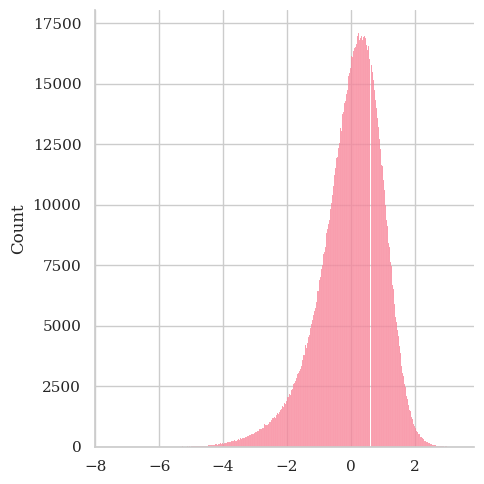

In [15]:
import seaborn as sns
x = X[:,:,:,:].flatten()
x = tl.to_numpy(x)
sns.displot(x)

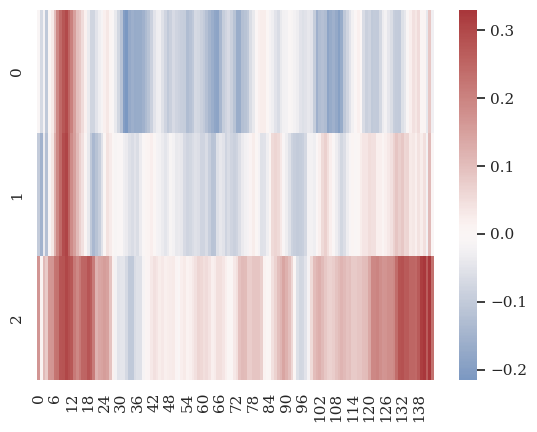

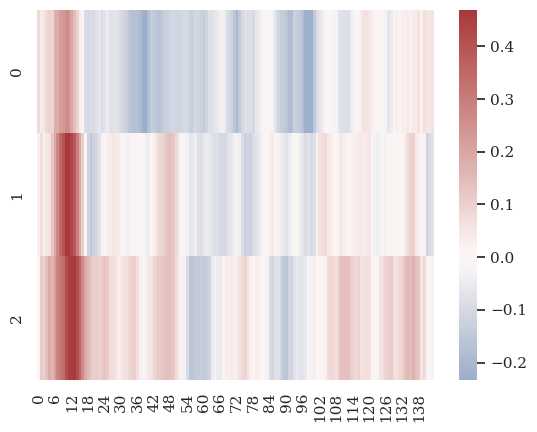

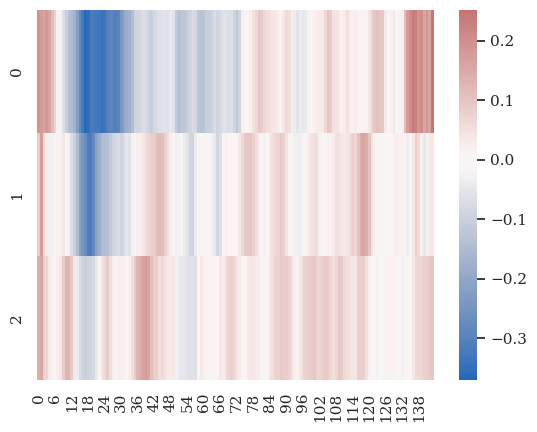

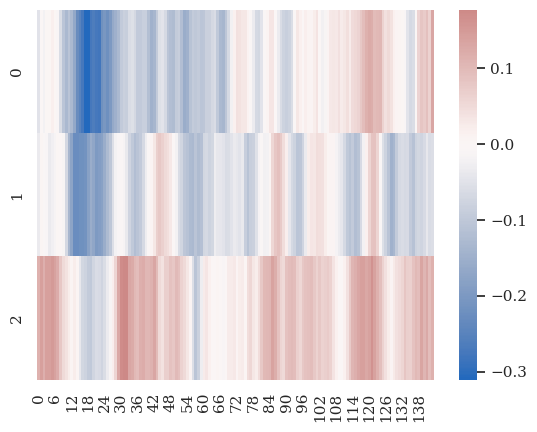

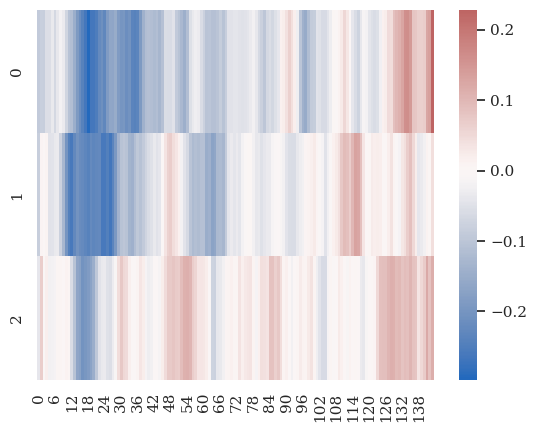

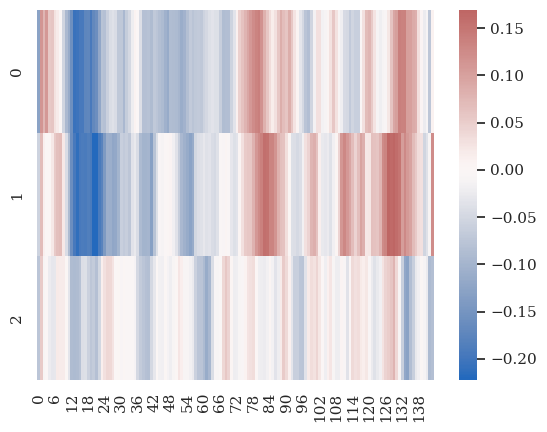

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

right_hand = tl.mean(X[y=='right_hand'],axis=0)
for band in range(right_hand.shape[0]):
    sns.heatmap(right_hand[band], cmap="vlag", center=0, square=False)
    plt.show()

/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning:

Mean of empty slice.

/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/numpy/core/_methods.py:121: RuntimeWarning:

invalid value encountered in divide

/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/seaborn/matrix.py:202: RuntimeWarning:

All-NaN slice encountered

/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/seaborn/matrix.py:207: RuntimeWarning:

All-NaN slice encountered



(6, 3, 144)


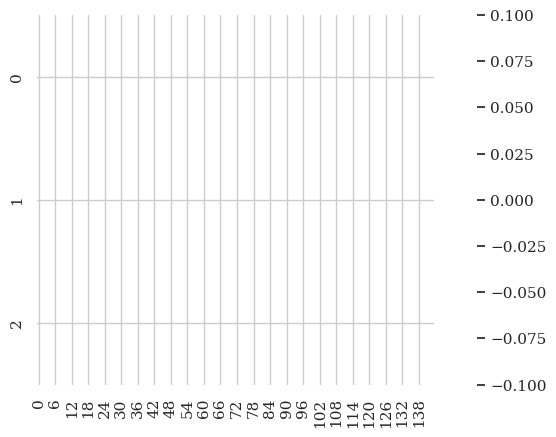

/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/seaborn/matrix.py:202: RuntimeWarning:

All-NaN slice encountered

/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/seaborn/matrix.py:207: RuntimeWarning:

All-NaN slice encountered



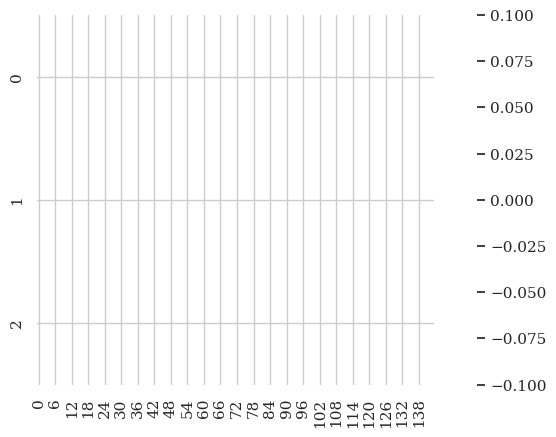

/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/seaborn/matrix.py:202: RuntimeWarning:

All-NaN slice encountered

/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/seaborn/matrix.py:207: RuntimeWarning:

All-NaN slice encountered



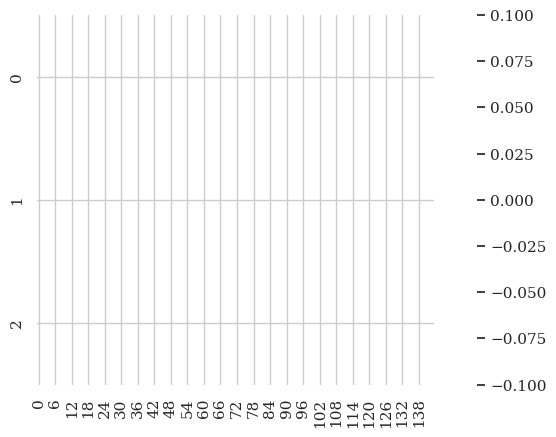

/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/seaborn/matrix.py:202: RuntimeWarning:

All-NaN slice encountered

/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/seaborn/matrix.py:207: RuntimeWarning:

All-NaN slice encountered



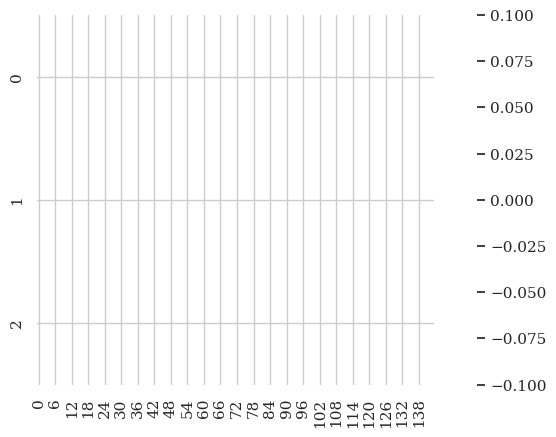

/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/seaborn/matrix.py:202: RuntimeWarning:

All-NaN slice encountered

/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/seaborn/matrix.py:207: RuntimeWarning:

All-NaN slice encountered



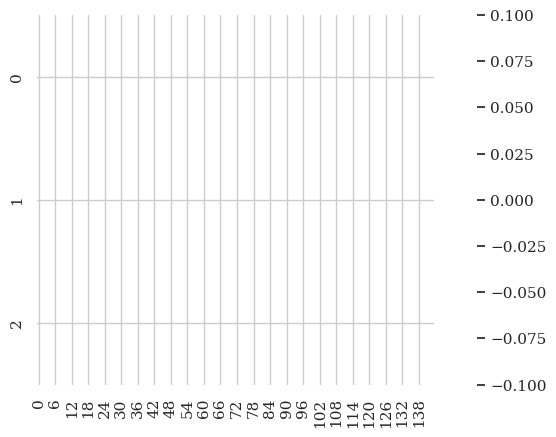

/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/seaborn/matrix.py:202: RuntimeWarning:

All-NaN slice encountered

/data/leuven/352/vsc35289/miniconda3/envs/hoda-bci/lib/python3.11/site-packages/seaborn/matrix.py:207: RuntimeWarning:

All-NaN slice encountered



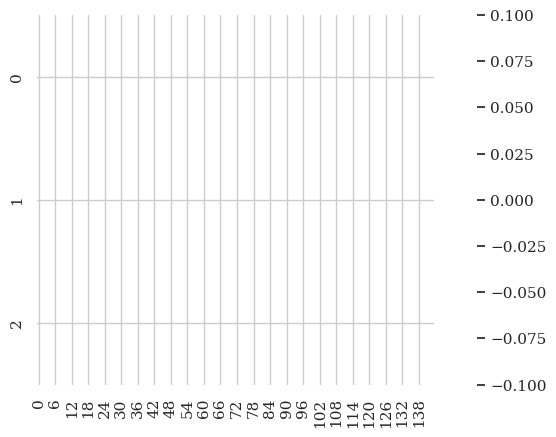

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

contrast = tl.mean(X[y=='right_hand'],axis=0)- tl.mean(X[y=='feet'], axis=0)
print(contrast.shape)
for band in range(contrast.shape[0]):
    sns.heatmap(contrast[band], cmap="vlag", center=0, square=False)
    plt.show()

In [32]:
from hoda.hoda import HODA

hoda = HODA(
        rank=None,
        max_iter=1024,
        tol=1e-6,
        shrinkage='lw',
        toeplitz=None,
        obj='tr',
        solver='lanczos',
        taper=False,
        extra_train_info=False,
        verbose=True,
        forward=True,
        theta=0.5,
        refit_shrinkage=True,
)


In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('default')

hoda.fit_backward(X,y)
df = pd.DataFrame(hoda.train_info_['backward'])
display(df)

/vsc-hard-mounts/leuven-data/352/vsc35289/hoda-bci/src/hoda/util.py:31: RuntimeWarning:

k >= N for N * N square matrix. Attempting to use scipy.linalg.eigh instead.

Backward HODA model rank=(3, 2, 11):   1%|▏         | 15/1024 [00:02<02:25,  6.92it/s]


,iteration,mode,flip,update,shrinkage,objective
0,1,1,1,1.170465e+00,0.006675,978572.274398
1,1,2,2,1.707692e+00,0.001649,985336.319525
2,1,3,3,1.411044e+00,0.009567,260902.840918
3,2,1,4,1.526323e+00,0.034440,980165.015009
4,2,2,5,1.996388e+00,0.004753,983786.795245
5,2,3,6,1.160692e+00,0.009923,163193.864169
6,3,1,7,1.215209e+00,0.055008,948664.533586
7,3,2,8,2.671651e-02,0.007087,986266.817333
8,3,3,9,1.234344e+00,0.010216,105877.937224
9,4,1,10,2.177259e-02,0.063977,949334.661499


In [34]:
df['flip'] = (df['iteration']-1)*2+df['mode']
df

,iteration,mode,flip,update,shrinkage,objective
0,1,1,1,1.170465e+00,0.006675,978572.274398
1,1,2,2,1.707692e+00,0.001649,985336.319525
2,1,3,3,1.411044e+00,0.009567,260902.840918
3,2,1,3,1.526323e+00,0.034440,980165.015009
4,2,2,4,1.996388e+00,0.004753,983786.795245
5,2,3,5,1.160692e+00,0.009923,163193.864169
6,3,1,5,1.215209e+00,0.055008,948664.533586
7,3,2,6,2.671651e-02,0.007087,986266.817333
8,3,3,7,1.234344e+00,0.010216,105877.937224
9,4,1,7,2.177259e-02,0.063977,949334.661499


In [35]:
import plotly.express as px

if hoda.extra_train_info:
    fig = px.line(df, x='flip', y='F_tr', log_y=False)
    fig.show()

In [36]:
px.line(df, x='iteration', y='update', log_y=True, color='mode')


In [37]:
px.line(df, x='flip', y='shrinkage', log_y=True, color='mode')

In [38]:
px.line(df, x='flip', y='objective', log_y=True, color='mode')

In [39]:
hoda.fit_forward(X,y)
df = pd.DataFrame(hoda.train_info_['forward'])
df

Forward model :   1%|          | 10/1023 [00:00<00:23, 42.41it/s]


,iteration,mode,flip,update,lambda_
0,1,1,1,1.070772e-01,0.0
1,1,2,2,1.339801e-01,0.0
2,1,3,3,8.172763e-01,0.0
3,2,1,4,7.813431e-02,0.0
4,2,2,5,5.258322e-02,0.0
5,2,3,6,1.339495e-01,0.0
6,3,1,7,2.287449e-02,0.0
7,3,2,8,1.068928e-02,0.0
8,3,3,9,3.274287e-02,0.0
9,4,1,10,5.438510e-03,0.0


In [40]:
df['flip'] = (df['iteration']-1)*2+df['mode']
df

,iteration,mode,flip,update,lambda_
0,1,1,1,1.070772e-01,0.0
1,1,2,2,1.339801e-01,0.0
2,1,3,3,8.172763e-01,0.0
3,2,1,3,7.813431e-02,0.0
4,2,2,4,5.258322e-02,0.0
5,2,3,5,1.339495e-01,0.0
6,3,1,5,2.287449e-02,0.0
7,3,2,6,1.068928e-02,0.0
8,3,3,7,3.274287e-02,0.0
9,4,1,7,5.438510e-03,0.0


In [41]:
if hoda.extra_train_info:
    px.line(df, x='flip', y='mse', log_y=True)

In [42]:
px.line(df, x='flip', y='update', log_y=True, color='mode')

In [43]:
from sklearn.feature_selection import SelectFpr, SelectFwe, SelectFdr
import numpy as np

Xt = hoda.transform(X)
xt = tl.to_numpy(tl.unfold(Xt,0))

select = SelectFdr(alpha=.05)
xts = select.fit_transform(xt,y)

df = pd.DataFrame({
    'feature': np.arange(xt.shape[-1]),
    'F': select.scores_,
    'p_value': select.pvalues_,
    'significant': select.get_support()
})
df

,feature,F,p_value,significant
0,0,3.890384,4.894664e-02,False
1,1,1.395371,2.378913e-01,False
2,2,0.043955,8.339973e-01,False
3,3,0.041447,8.387360e-01,False
4,4,4.389455,3.651164e-02,False
...,...,...,...,...
61,61,0.654123,4.189102e-01,False
62,62,0.438229,5.081908e-01,False
63,63,0.503188,4.783329e-01,False
64,64,2.649287,1.040351e-01,False


In [46]:
fig = px.bar(df, x='feature', y='F', color='significant')
fig.update_xaxes(type='category', categoryorder='total descending')
fig.show()

In [45]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
x_viz = PCA(n_components=2).fit_transform(xts)
px.scatter(x=x_viz[:,0], y=x_viz[:,1], color=y)